# Demo 1: Systematic Model Selection for Health Data

This demo shows how to implement systematic model selection using cross-validation techniques. We'll use a patient readmission prediction dataset to demonstrate different validation strategies and their importance in healthcare applications.

## Setup

First, we need to install and import the necessary libraries:

In [1]:
# Install required packages
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost

%reset -f

# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, make_scorer
from sklearn.preprocessing import StandardScaler
from IPython.display import display
import warnings

# Filter out specific warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Load and Prepare Data

We'll use a synthetic patient readmission dataset for this demo. In real healthcare applications, you would use actual patient data with proper privacy considerations.

In [2]:
# Generate synthetic patient data
np.random.seed(42)
n_samples = 1000

# Create synthetic features
data = {
    'age': np.random.normal(65, 15, n_samples),
    'length_of_stay': np.random.exponential(5, n_samples),
    'num_medications': np.random.poisson(8, n_samples),
    'num_diagnoses': np.random.poisson(5, n_samples),
    'emergency_admission': np.random.binomial(1, 0.3, n_samples)
}

# Create target variable (readmission within 30 days)
# More complex relationship to make it interesting
readmission_prob = (
    0.1 +  # Base probability
    0.01 * (data['age'] - 65) +  # Age effect
    0.05 * data['length_of_stay'] +  # Length of stay effect
    0.02 * data['num_medications'] +  # Medication effect
    0.03 * data['num_diagnoses'] +  # Diagnosis effect
    0.1 * data['emergency_admission']  # Emergency admission effect
)
readmission_prob = np.clip(readmission_prob, 0, 1)  # Clip to valid probability range
data['readmission'] = np.random.binomial(1, readmission_prob)

# Convert to DataFrame
df = pd.DataFrame(data)

# Display basic statistics
print("Dataset Summary:")
display(df.describe())
print("\nClass Distribution:")
display(df['readmission'].value_counts(normalize=True))

Dataset Summary:


,age,length_of_stay,num_medications,num_diagnoses,emergency_admission,readmission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,65.289981,5.039930,7.912000,4.989000,0.312000,0.651000
std,14.688239,5.014943,2.628529,2.296988,0.463542,0.476892
min,16.380990,0.016117,1.000000,0.000000,0.000000,0.000000
25%,55.286145,1.419773,6.000000,3.000000,0.000000,0.000000
50%,65.379509,3.629656,8.000000,5.000000,0.000000,1.000000
75%,74.719158,6.858421,10.000000,7.000000,1.000000,1.000000
max,122.790972,37.208615,16.000000,15.000000,1.000000,1.000000



Class Distribution:


readmission
1    0.651
0    0.349
Name: proportion, dtype: float64

## Visualize Data Distribution

Understanding the data distribution is crucial in healthcare applications. Let's explore the relationships between features and the target variable:

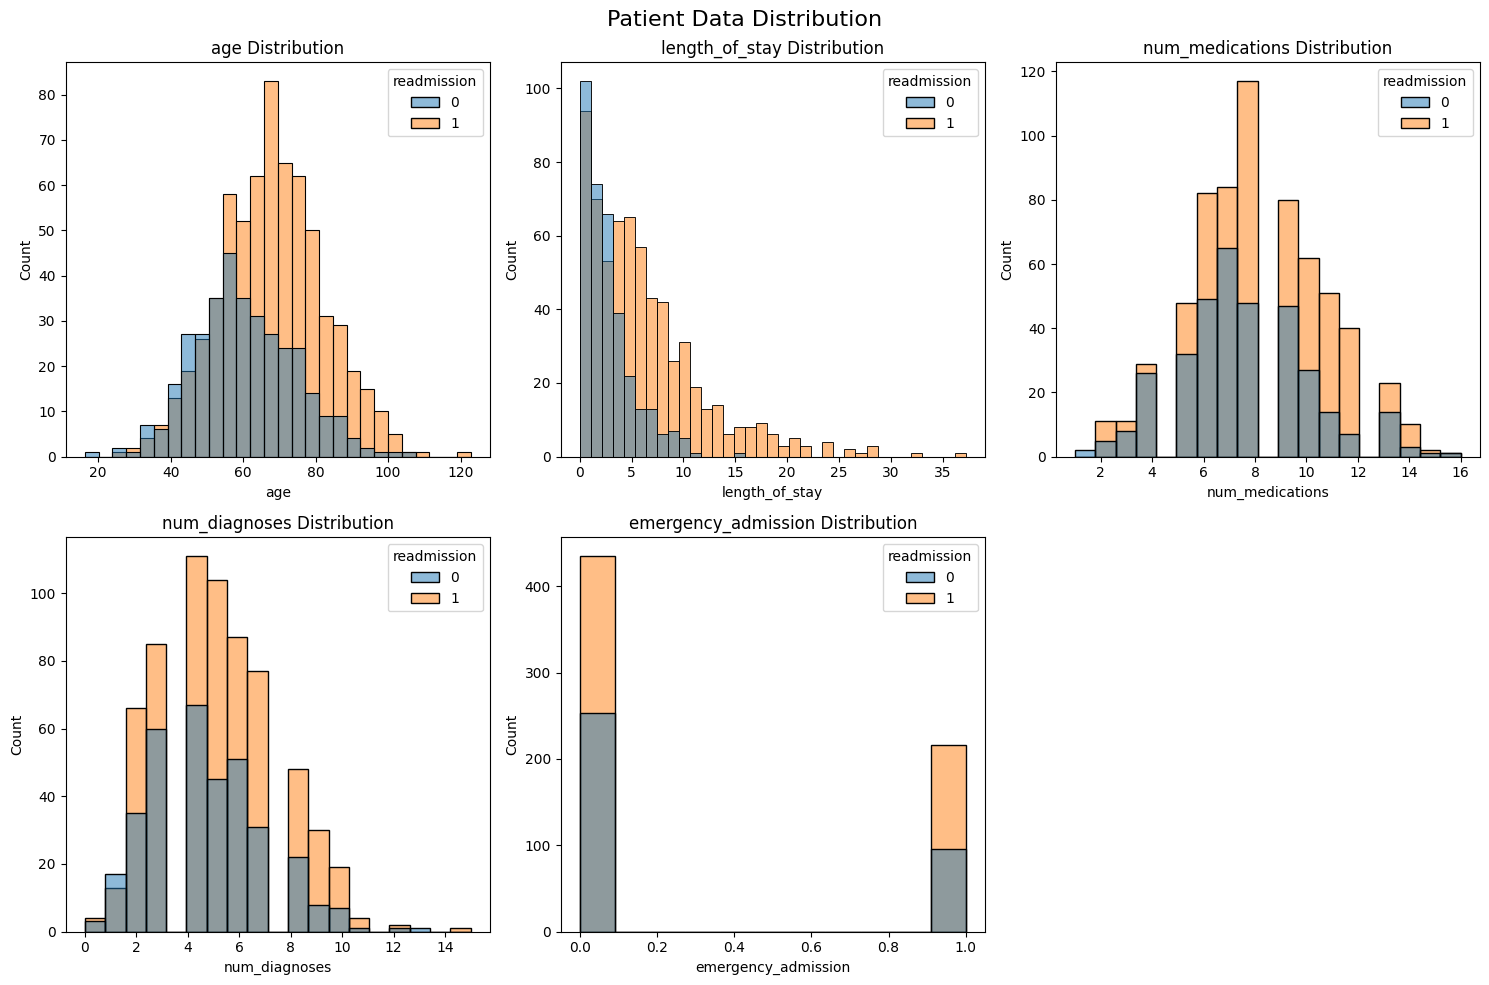

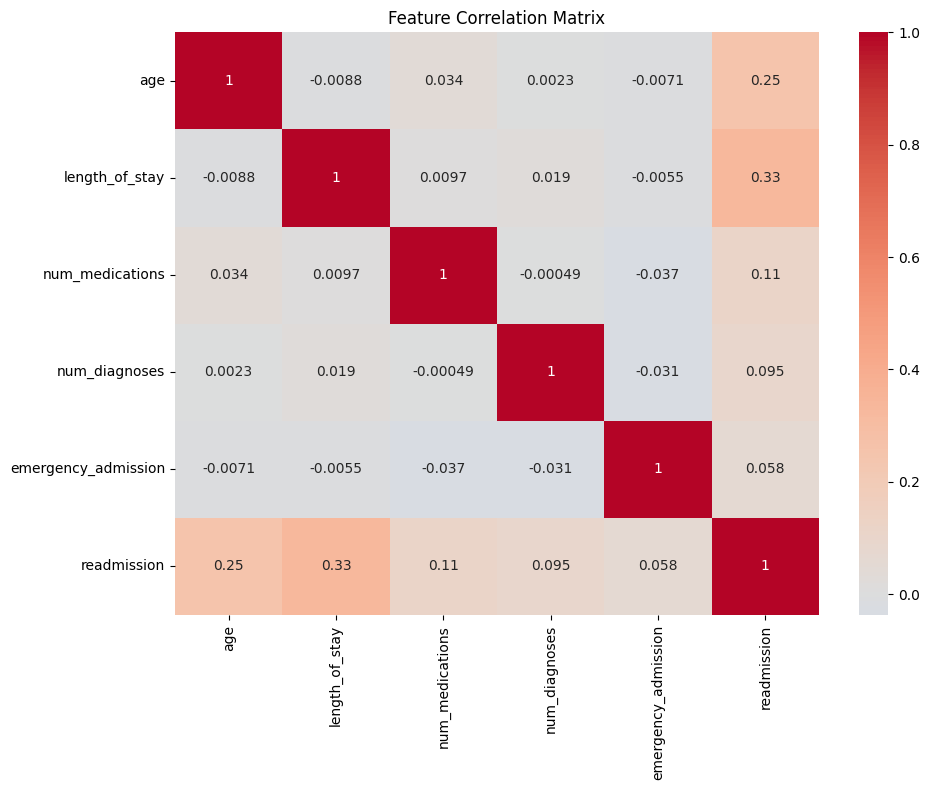

In [3]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Patient Data Distribution', fontsize=16)

# Plot histograms for each feature
features = ['age', 'length_of_stay', 'num_medications', 'num_diagnoses', 'emergency_admission']
for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    sns.histplot(data=df, x=feature, hue='readmission', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} Distribution')

# Remove empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Feature Scaling

Feature scaling is a crucial preprocessing step in machine learning. It helps ensure that all features contribute equally to the model's predictions, regardless of their original scales. This is particularly important for:

1. **Gradient-based algorithms** (like Logistic Regression) that are sensitive to feature scales
2. **Distance-based algorithms** where features with larger scales would dominate the calculations
3. **Regularization** where unscaled features can lead to biased regularization effects

In healthcare applications, different features often have very different scales:
- Age might range from 0-100
- Length of stay might be in days (0-30)
- Number of medications might be 0-20
- Emergency admission is binary (0-1)

Let's see how scaling affects our features:

Original Feature Statistics:


,age,length_of_stay,num_medications,num_diagnoses,emergency_admission
count,800.000000,800.000000,800.000000,800.000000,800.000000
mean,65.082741,5.129282,7.937500,4.991250,0.323750
std,14.694259,5.189891,2.692611,2.277643,0.468199
min,16.380990,0.016117,1.000000,0.000000,0.000000
25%,55.219504,1.479012,6.000000,3.000000,0.000000
50%,65.242608,3.637875,8.000000,5.000000,0.000000
75%,74.650791,6.972123,10.000000,6.000000,1.000000
max,122.790972,37.208615,16.000000,15.000000,1.000000



Scaled Feature Statistics:


,age,length_of_stay,num_medications,num_diagnoses,emergency_admission
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,800.000000
mean,1.859624e-16,-1.676437e-16,-1.110223e-17,8.881784e-18,0.000000
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626
min,-3.316412e+00,-9.858325e-01,-2.578107e+00,-2.192781e+00,-0.691913
25%,-6.716506e-01,-7.037822e-01,-7.200118e-01,-8.748059e-01,-0.691913
50%,1.088631e-02,-2.875474e-01,2.322619e-02,3.844094e-03,-0.691913
75%,6.515494e-01,3.553050e-01,7.664642e-01,4.431691e-01,1.445269
max,3.929721e+00,6.184985e+00,2.996178e+00,4.397094e+00,1.445269


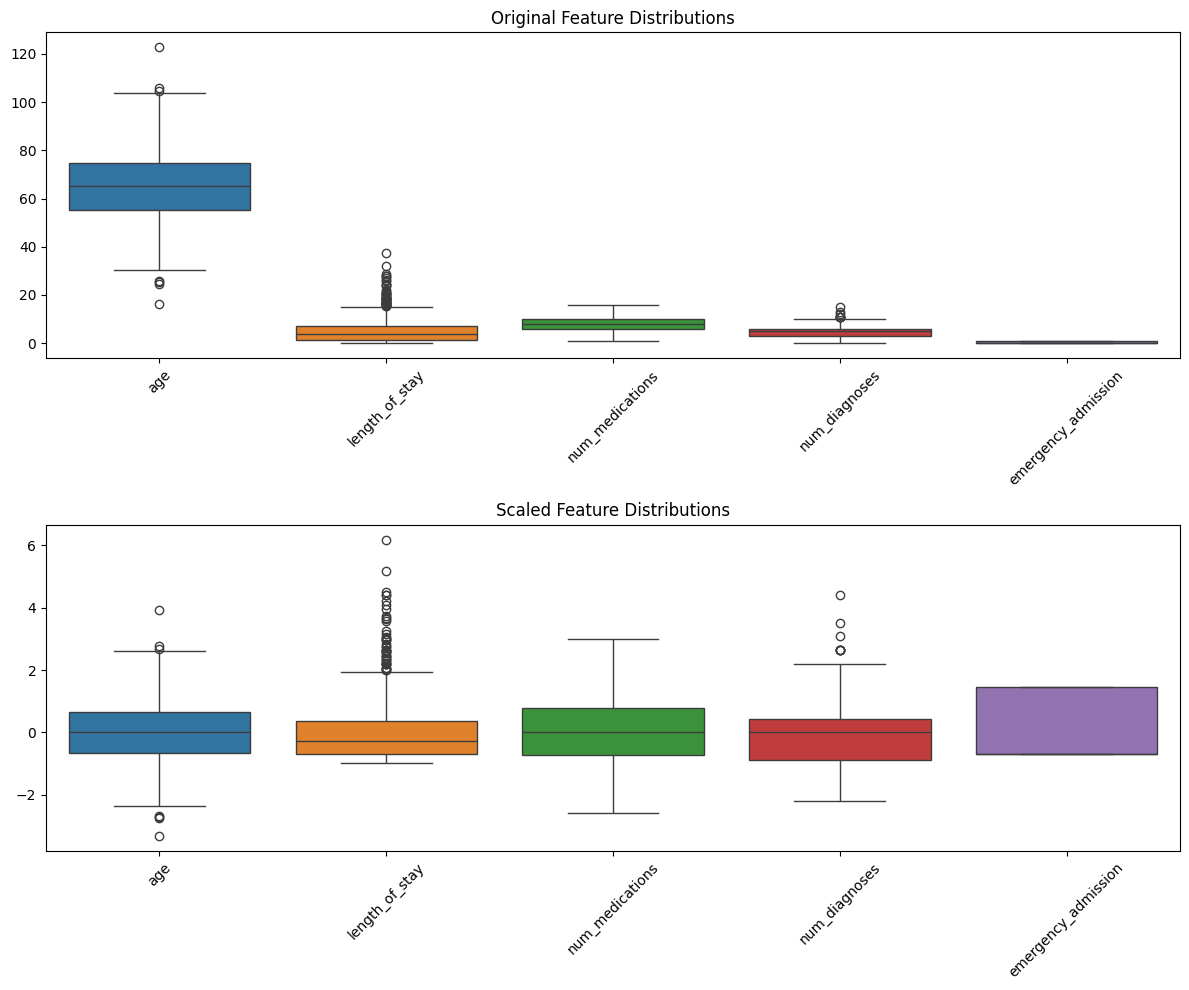

,Dataset Size,Readmission Rate
Training Set,800,0.65125
Holdout Set,200,0.65000


In [4]:
# Split into training and holdout sets
X = df.drop('readmission', axis=1)
y = df['readmission']

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

# Convert scaled arrays back to DataFrames for easier comparison
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Display comparison of original vs scaled features
print("Original Feature Statistics:")
display(X_train.describe())
print("\nScaled Feature Statistics:")
display(X_train_scaled_df.describe())

# Visualize the effect of scaling
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Original features
sns.boxplot(data=X_train, ax=axes[0])
axes[0].set_title('Original Feature Distributions')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Scaled features
sns.boxplot(data=X_train_scaled_df, ax=axes[1])
axes[1].set_title('Scaled Feature Distributions')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    'Dataset Size': [X_train.shape[0], X_holdout.shape[0]],
    'Readmission Rate': [y_train.mean(), y_holdout.mean()]
}, index=['Training Set', 'Holdout Set']))

## Model Selection with Repeated K-Fold Cross-Validation

We'll compare three models using repeated stratified k-fold cross-validation with F1 score as our evaluation metric. Note that we'll use the scaled features for all models to ensure fair comparison:


Evaluating Random Forest...


Mean F1 Score: 0.787 (+/- 0.042)

Evaluating XGBoost...


Mean F1 Score: 0.740 (+/- 0.048)

Evaluating Logistic Regression...
Mean F1 Score: 0.788 (+/- 0.049)


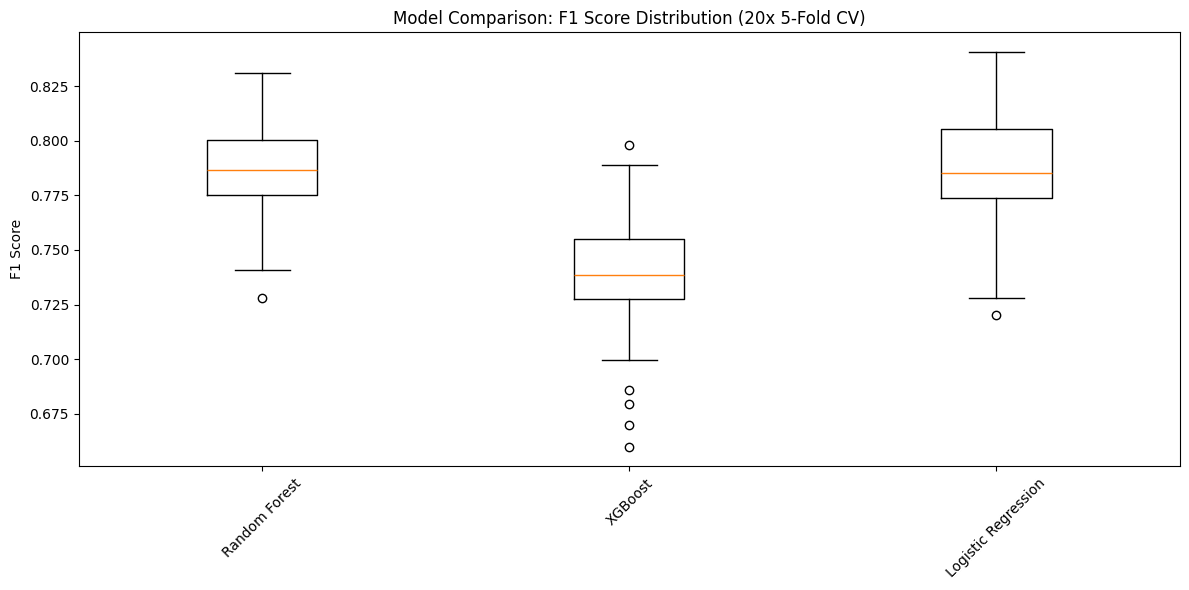

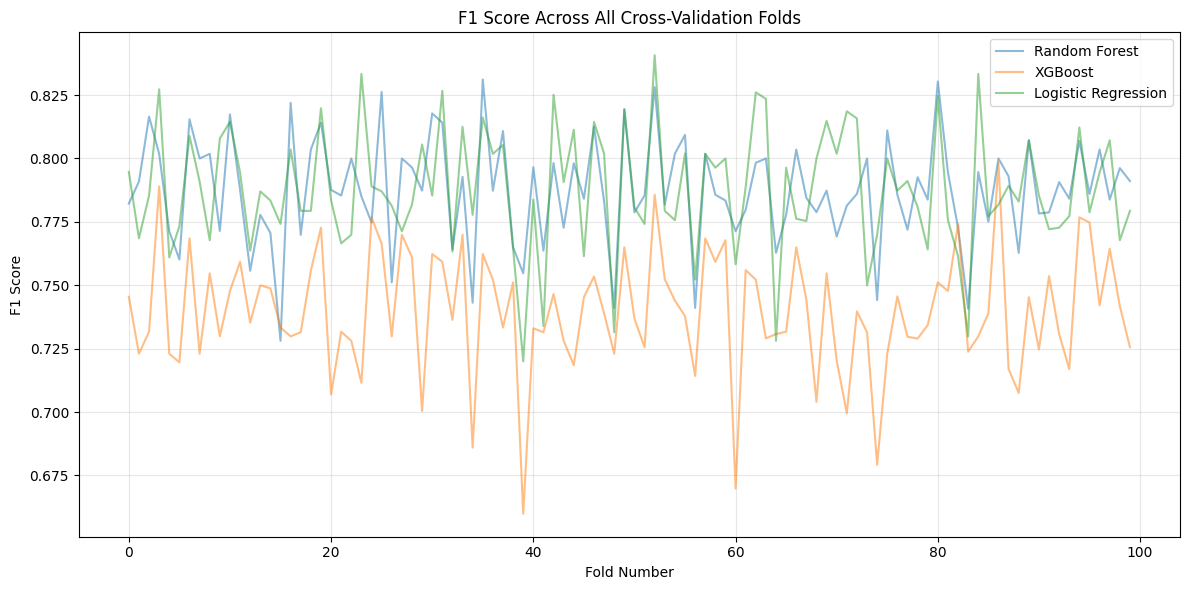

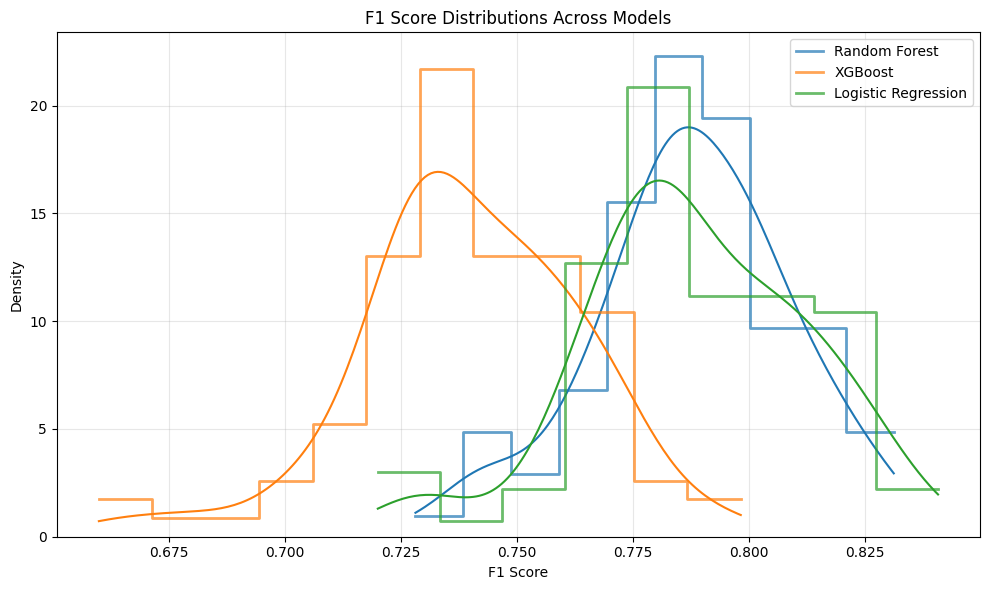


Detailed Model Statistics:

Random Forest:
Mean F1 Score: 0.787
Std F1 Score: 0.021
Min F1 Score: 0.728
Max F1 Score: 0.831
95% Confidence Interval: [0.741, 0.827]

XGBoost:
Mean F1 Score: 0.740
Std F1 Score: 0.024
Min F1 Score: 0.660
Max F1 Score: 0.798
95% Confidence Interval: [0.682, 0.781]

Logistic Regression:
Mean F1 Score: 0.788
Std F1 Score: 0.024
Min F1 Score: 0.720
Max F1 Score: 0.841
95% Confidence Interval: [0.731, 0.830]


In [5]:
# Initialize models with optimized hyperparameters
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=5,  # Prevent overfitting
        min_samples_split=10,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,
        max_depth=4,              # Try 4 or 5 for more complexity
        learning_rate=0.05,       # Lower learning rate, more boosting rounds
        subsample=0.9,            # Slightly more data per tree
        colsample_bytree=0.9,     # Slightly more features per tree
        min_child_weight=1,       # Allow splits with fewer samples
        gamma=0,                  # No minimum loss reduction for split
        reg_alpha=0.01,           # L1 regularization
        reg_lambda=0.1,           # L2 regularization
        use_label_encoder=False,  # Suppress warning
        eval_metric='logloss',    # Suppress warning
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs',
        C=1.0  # Regularization strength
    )
}

# Initialize repeated k-fold cross-validation
n_splits = 5
n_repeats = 20
rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

# Store results
results = {}

# Perform cross-validation for each model
for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # Perform cross-validation using scaled features
    cv_scores = cross_val_score(
        model, 
        X_train_scaled, 
        y_train,
        cv=rskf,
        scoring='f1'
    )
    
    results[name] = cv_scores
    
    # Print results
    print(f"Mean F1 Score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Visualize results with boxplots
plt.figure(figsize=(12, 6))
plt.boxplot([results[name] for name in models.keys()], tick_labels=models.keys())
plt.title('Model Comparison: F1 Score Distribution (20x 5-Fold CV)')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create a more detailed comparison plot
plt.figure(figsize=(12, 6))
for name, scores in results.items():
    plt.plot(range(len(scores)), scores, label=name, alpha=0.5)
plt.title('F1 Score Across All Cross-Validation Folds')
plt.xlabel('Fold Number')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize F1 score distributions with KDE curves only (no normal overlays)
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (name, scores) in enumerate(results.items()):
    sns.histplot(scores, kde=True, stat='density', label=name, color=colors[i], element='step', fill=False, linewidth=2, alpha=0.7)

plt.title('F1 Score Distributions Across Models')
plt.xlabel('F1 Score')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print detailed statistics for each model
print("\nDetailed Model Statistics:")
for name, scores in results.items():
    print(f"\n{name}:")
    print(f"Mean F1 Score: {np.mean(scores):.3f}")
    print(f"Std F1 Score: {np.std(scores):.3f}")
    print(f"Min F1 Score: {np.min(scores):.3f}")
    print(f"Max F1 Score: {np.max(scores):.3f}")
    print(f"95% Confidence Interval: [{np.percentile(scores, 2.5):.3f}, {np.percentile(scores, 97.5):.3f}]")

## Final Model Evaluation

Now we'll train the best performing model on the full training set and evaluate it on the holdout set:

In [6]:
# Identify best model
best_model_name = max(results, key=lambda x: np.mean(results[x]))
best_model = models[best_model_name]

print(f"\nBest performing model: {best_model_name}")

# Train on full training set using scaled features
best_model.fit(X_train_scaled, y_train)

# Evaluate on holdout set using scaled features
holdout_pred = best_model.predict(X_holdout_scaled)
holdout_f1 = f1_score(y_holdout, holdout_pred)

display(pd.DataFrame({
    'Metric': ['Holdout F1 Score', 'Mean CV F1 Score', 'CV F1 Score Std'],
    'Value': [
        f"{holdout_f1:.3f}",
        f"{np.mean(results[best_model_name]):.3f}",
        f"{np.std(results[best_model_name]):.3f}"
    ]
}))


Best performing model: Logistic Regression


,Metric,Value
0,Holdout F1 Score,0.752
1,Mean CV F1 Score,0.788
2,CV F1 Score Std,0.024


## Why doesn't XGBoost always win?

- XGBoost is powerful for complex, high-dimensional, or highly non-linear data.
- On simple, mostly linear, or low-dimensional data, simpler models (like logistic regression or random forest) can match or outperform it.
- Always compare multiple models and tune hyperparameters—there's no "one-size-fits-all" winner in machine learning!

## Key Takeaways

1. **Systematic Model Selection**
   - Global holdout set for final evaluation
   - Repeated k-fold cross-validation for robust performance estimation
   - Consistent folds across models for fair comparison
   - F1 score as evaluation metric for imbalanced classification

2. **Model Comparison**
   - Multiple models evaluated (Random Forest, XGBoost, Logistic Regression)
   - Distribution of performance across folds
   - Statistical significance of differences

3. **Healthcare-Specific Considerations**
   - Stratified sampling to maintain class distribution
   - F1 score as metric for imbalanced outcomes
   - Importance of robust validation in clinical applications

4. **Best Practices**
   - Use of repeated cross-validation for stable estimates
   - Separate holdout set for final evaluation
   - Consistent evaluation across models
   - Visualization of performance distributions
   - Proper feature scaling for all models to ensure fair comparison
   - Understanding the impact of scaling on model performance 